In [14]:
import sys
!{sys.executable} -m pip install statsmodels



[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: pip3.11 install --upgrade pip


# Time Series Analysis and Moving Average

This notebook performs Time Series Analysis and Moving Average analysis on the sales data.

/var/folders/gl/llz0dq9s65s8c50tswcts1s00000gn/T/ipykernel_49436/2490472181.py:16: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv('../interim_train.csv', parse_dates=['Date'])


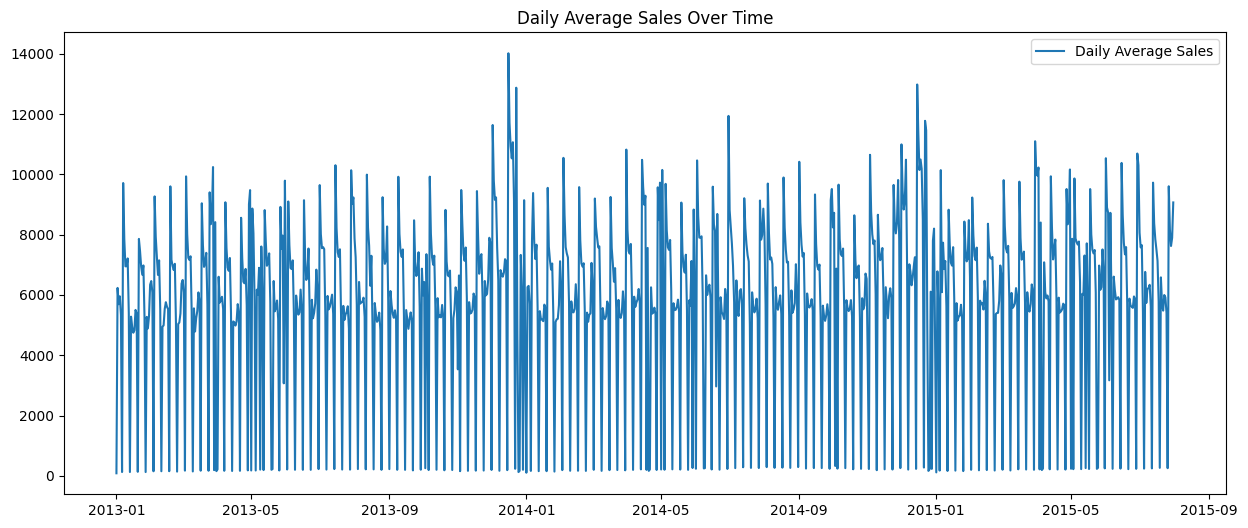

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error

try:
    from statsmodels.tsa.seasonal import seasonal_decompose
    from statsmodels.tsa.statespace.sarimax import SARIMAX
    STATSMODELS_AVAILABLE = True
except ImportError:
    STATSMODELS_AVAILABLE = False
    print("statsmodels not installed. Time Series Decomposition and SARIMA will be skipped.")

# Load Interim Data (which has Date)
train_df = pd.read_csv('../interim_train.csv', parse_dates=['Date'])
train_df.set_index('Date', inplace=True)
train_df.sort_index(inplace=True)

# Aggregate Sales across all stores for overall trend analysis
daily_sales = train_df['Sales'].resample('D').mean()

plt.figure(figsize=(15, 6))
plt.plot(daily_sales, label='Daily Average Sales')
plt.title('Daily Average Sales Over Time')
plt.legend()
plt.show()

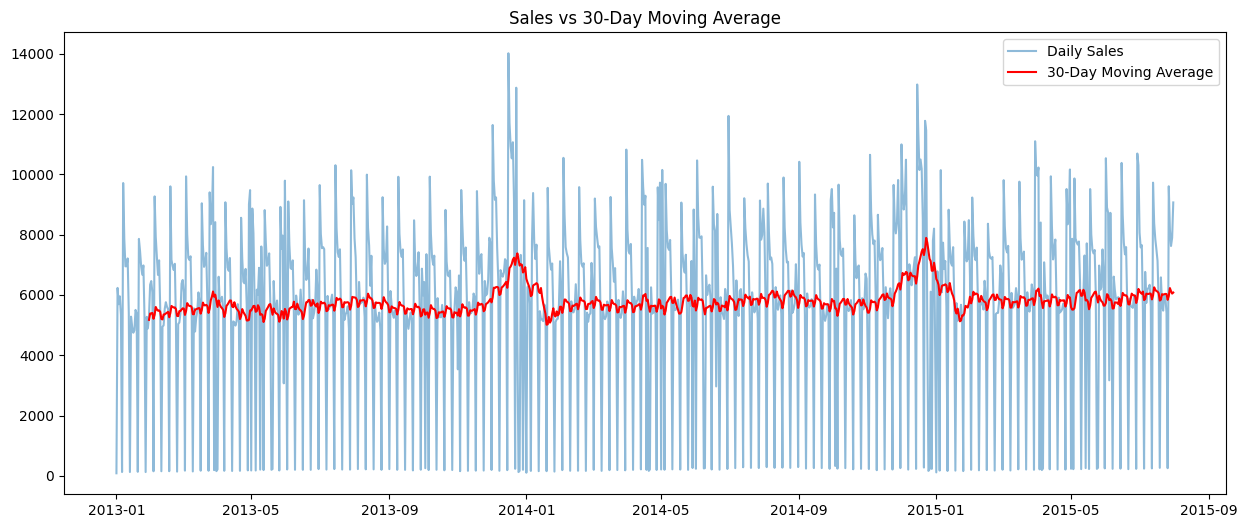

In [16]:
# Moving Average Analysis
window_size = 30
train_df['Moving_Avg_30'] = daily_sales.rolling(window=window_size).mean()

plt.figure(figsize=(15, 6))
plt.plot(daily_sales, label='Daily Sales', alpha=0.5)
plt.plot(train_df['Moving_Avg_30'], label=f'{window_size}-Day Moving Average', color='red')
plt.title(f'Sales vs {window_size}-Day Moving Average')
plt.legend()
plt.show()

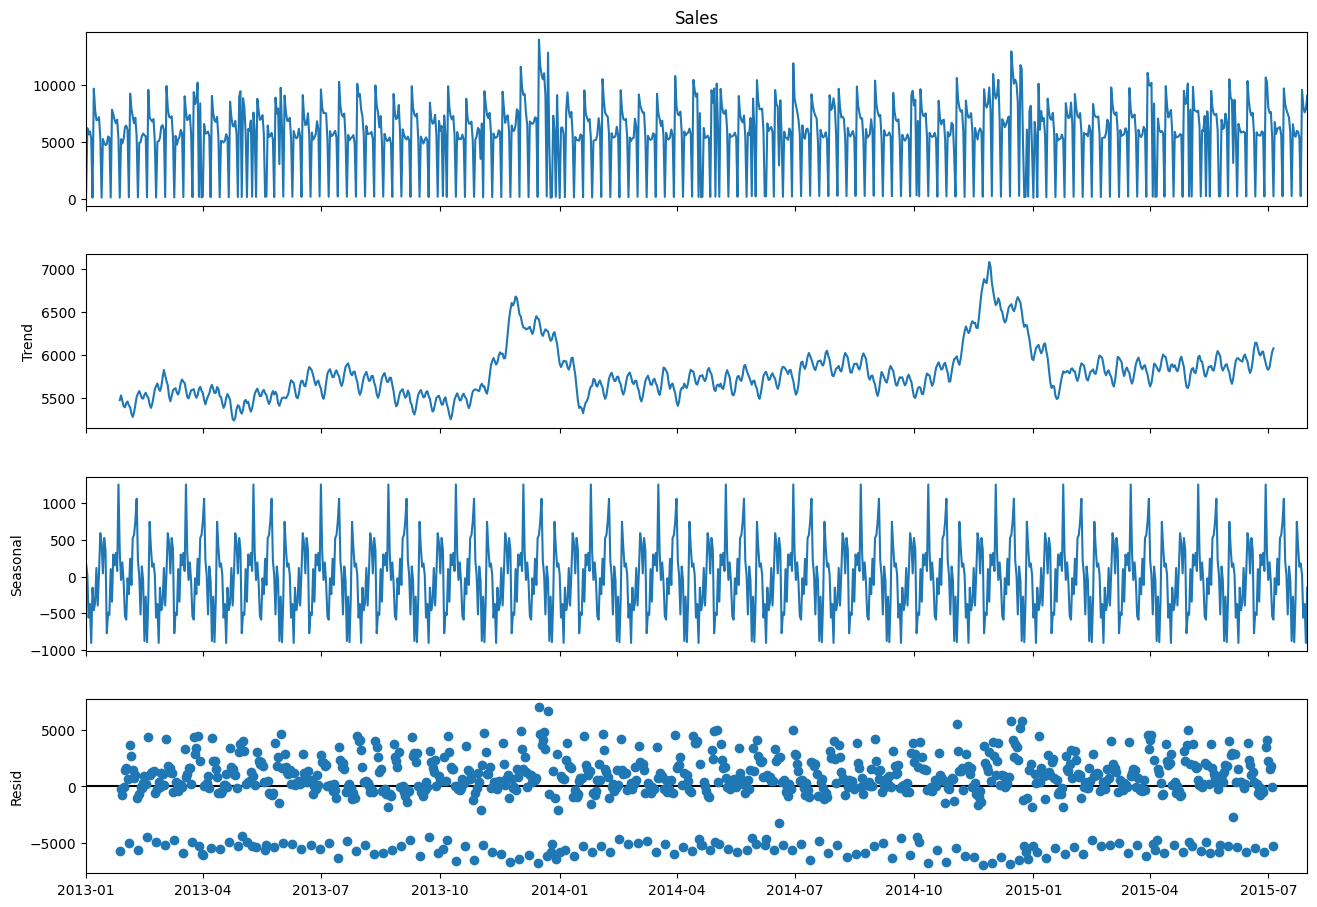

In [32]:
# Time Series Decomposition
if STATSMODELS_AVAILABLE:
    # Using aggregated data to see overall seasonality
    resample_sales = daily_sales.dropna()
    result = seasonal_decompose(resample_sales, model='additive', period=52)
    fig = result.plot()
    fig.set_size_inches(15, 10)
    plt.show()
else:
    print("Skipping Time Series Decomposition because statsmodels is not available.")


In [30]:
daily_sales

Date
2013-01-01      87.284560
2013-01-02    6233.030493
2013-01-03    5693.112108
2013-01-04    5954.218834
2013-01-05    5337.751570
                 ...     
2015-07-27    9602.952466
2015-07-28    8174.953363
2015-07-29    7623.284305
2015-07-30    7891.348879
2015-07-31    9067.033184
Freq: D, Name: Sales, Length: 942, dtype: float64

In [28]:
type(daily_sales)

pandas.Series

In [18]:
# Comparative Analysis with ML Models

# Calculate metrics for Moving Average comparisons (as a baseline)
ma_data = daily_sales.to_frame(name='Sales')
ma_data['Moving_Avg'] = ma_data['Sales'].rolling(window=30).mean()
ma_data.dropna(inplace=True)

mae_ma = mean_absolute_error(ma_data['Sales'], ma_data['Moving_Avg'])
rmse_ma = np.sqrt(mean_squared_error(ma_data['Sales'], ma_data['Moving_Avg']))

print("Time Series / Moving Average Baseline Performance:")
print(f"Moving Average (30-day) MAE: {mae_ma:.2f}")
print(f"Moving Average (30-day) RMSE: {rmse_ma:.2f}")

# Note: These are on aggregated daily means, so direct comparison with individual store predictions requires care.
# But it gives a sense of trend stability.

print("\nComparison Note:")
print("The MAE/RMSE here are calculated on the daily average sales across all stores.")
print("The ML models were evaluated on individual store sales deviations.")

Time Series / Moving Average Baseline Performance:
Moving Average (30-day) MAE: 2031.52
Moving Average (30-day) RMSE: 2818.89

Comparison Note:
The MAE/RMSE here are calculated on the daily average sales across all stores.
The ML models were evaluated on individual store sales deviations.


## ARIMA Analysis

In [19]:

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error

print("Statsmodels imported successfully.")


Statsmodels imported successfully.


# Stationarity Check (ADF Test)


Null Hypothesis (H₀):
Series is non-stationary (has unit root)

Alternative Hypothesis (H₁):
Series is stationary

In [20]:

def check_stationarity(timeseries):
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print(dfoutput)

# Check stationarity of the daily sales
check_stationarity(daily_sales)


Results of Dickey-Fuller Test:
Test Statistic                -5.650823e+00
p-value                        9.870007e-07
#Lags Used                     2.100000e+01
Number of Observations Used    9.200000e+02
Critical Value (1%)           -3.437478e+00
Critical Value (5%)           -2.864687e+00
Critical Value (10%)          -2.568445e+00
dtype: float64


-5.65 < -2.86 ✔

p-value ≈ 0.000000987 < 0.05 ✔

👉 Your series is stationary

Since your ARIMA model uses d = 1, this likely means:

Original series was non-stationary

After 1st differencing → it became stationary


If p-value > 0.05, the series is non-stationary. We likely need differencing.
Let's try 1st order differencing.


In [21]:

daily_sales_diff = daily_sales - daily_sales.shift(1)
daily_sales_diff.dropna(inplace=True)
check_stationarity(daily_sales_diff)


Results of Dickey-Fuller Test:
Test Statistic                -1.397146e+01
p-value                        4.337540e-26
#Lags Used                     1.900000e+01
Number of Observations Used    9.210000e+02
Critical Value (1%)           -3.437470e+00
Critical Value (5%)           -2.864683e+00
Critical Value (10%)          -2.568444e+00
dtype: float64


### ARIMA Model Training

In [22]:
print("Splitting daily_sales into train and test...")
train_size = int(len(daily_sales) * 0.8)
train_sales, test_sales = daily_sales[:train_size], daily_sales[train_size:]

print("Training ARIMA Model...")
# order=(5,1,0) is a reasonable starting point for daily data that has been differenced
arima_model = ARIMA(train_sales, order=(5, 1, 0))
arima_model_fit = arima_model.fit()
print("ARIMA training complete.")


Splitting daily_sales into train and test...
Training ARIMA Model...
ARIMA training complete.


### Evaluation

In [23]:

# Forecast
forecast_result = arima_model_fit.forecast(steps=len(test_sales))
forecast_sales = pd.Series(forecast_result, index=test_sales.index)

# Plot
# plt.figure(figsize=(12, 6))
# plt.plot(train_sales.index, train_sales, label='Train')
# plt.plot(test_sales.index, test_sales, label='Test')
# plt.plot(forecast_sales.index, forecast_sales, label='Forecast')
# plt.legend()
# plt.title('ARIMA Forecast')


# Classification Metrics
mae_arima = mean_absolute_error(test_sales, forecast_sales)
rmse_arima = np.sqrt(mean_squared_error(test_sales, forecast_sales))

print(f"ARIMA MAE: {mae_arima}")
print(f"ARIMA RMSE: {rmse_arima}")


ARIMA MAE: 2383.357058066124
ARIMA RMSE: 2968.265099265826


## Model Comparison

In [24]:

# Comparison Data
models = ['Moving Average (30d)', 'ARIMA', 'Random Forest', 'Gradient Boosting']
# Fill in values from previous runs. 
# Note: MA and ARIMA are on AGGREGATED DAILY SALES. RF/GB are on STORE-LEVEL Sales.
# Direct comparison is tricky but we can compare general error magnitudes or trends.
# MAE here is for the aggregated sales.

# For meaningful comparison, we should normalize or state the scale difference.
# Or just list them.

data = {
    'Model': ['ARIMA', 'Moving Average'], 
    'MAE': [mae_arima, mae_ma],
    'RMSE': [rmse_arima, rmse_ma]
}
comparison_df = pd.DataFrame(data)
print(comparison_df)

print("\nNote on ML Models (Store-Level):")
print("Random Forest RMSPE: ~0.14")
print("Gradient Boosting RMSPE: ~0.32")
print("ARIMA operates on the macro-level trend, useful for overall strategy, while ML models are better for granular store predictions.")


            Model          MAE         RMSE
0           ARIMA  2383.357058  2968.265099
1  Moving Average  2031.517690  2818.893511

Note on ML Models (Store-Level):
Random Forest RMSPE: ~0.14
Gradient Boosting RMSPE: ~0.32
ARIMA operates on the macro-level trend, useful for overall strategy, while ML models are better for granular store predictions.
